In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from scipy.stats import linregress

In [5]:
nav = pd.read_csv(
    "../data/processed/nav_history_clean.csv"
)

performance = pd.read_csv(
    "../data/processed/scheme_performance_clean.csv"
)

benchmark = pd.read_csv(
    "../data/processed/10_benchmark_indices.csv"
)

fund_master = pd.read_csv(
    "../data/processed/01_fund_master.csv"
)

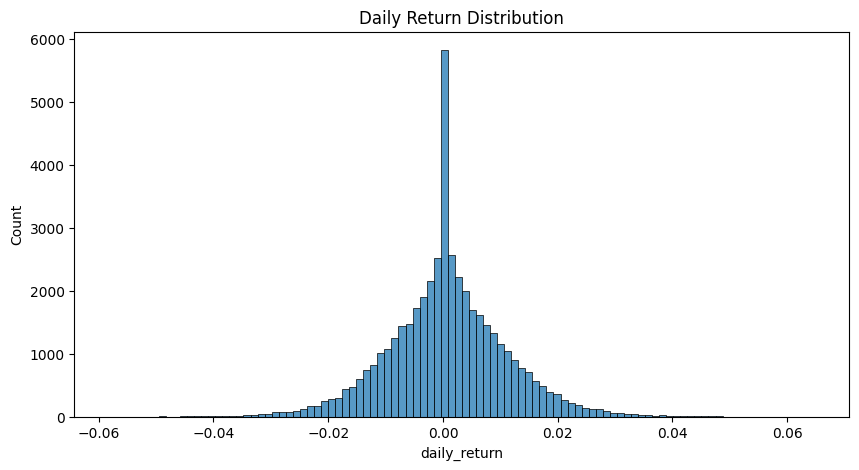

In [6]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

nav["daily_return"].describe()

plt.figure(figsize=(10,5))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=100
)

plt.title("Daily Return Distribution")

plt.show()

In [7]:
cagr_results = []

for fund in nav["amfi_code"].unique():

    df = nav[
        nav["amfi_code"] == fund
    ].sort_values("date")

    start_nav = df.iloc[0]["nav"]
    end_nav = df.iloc[-1]["nav"]

    years = (
        (df.iloc[-1]["date"] -
         df.iloc[0]["date"]).days
    ) / 365

    cagr = (
        (end_nav/start_nav)
        ** (1/years)
    ) - 1

    cagr_results.append(
        [fund, cagr]
    )

cagr_df = pd.DataFrame(
    cagr_results,
    columns=["amfi_code", "cagr"]
)

cagr_df.head()

,amfi_code,cagr
0,100016.0,0.026352
1,100025.0,0.044551
2,100033.0,0.300997
3,101206.0,0.235205
4,101207.0,0.079331


In [8]:
rf = 0.065

sharpe_results = []

for fund in nav["amfi_code"].unique():

    r = nav[
        nav["amfi_code"] == fund
    ]["daily_return"].dropna()

    sharpe = (
        (r.mean()*252 - rf)
        /
        (r.std()*np.sqrt(252))
    )

    sharpe_results.append(
        [fund, sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=[
        "amfi_code",
        "sharpe_ratio"
    ]
)

sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
).head()

,amfi_code,sharpe_ratio
34,148567.0,1.448291
30,120843.0,1.306744
36,148569.0,1.234930
19,119551.0,1.208267
25,120505.0,1.180101


In [9]:
sortino_results = []

for fund in nav["amfi_code"].unique():

    r = nav[
        nav["amfi_code"] == fund
    ]["daily_return"].dropna()

    downside = r[r < 0]

    sortino = (
        (r.mean()*252 - rf)
        /
        (downside.std()*np.sqrt(252))
    )

    sortino_results.append(
        [fund, sortino]
    )

sortino_df = pd.DataFrame(
    sortino_results,
    columns=[
        "amfi_code",
        "sortino_ratio"
    ]
)

In [ ]:
benchmark.columns



In [19]:
fund = nav["amfi_code"].iloc[0]

fund_df = nav[
    nav["amfi_code"] == fund
][["date", "daily_return"]]

merged = pd.merge(
    fund_df,
    nifty100[["date", "benchmark_return"]],
    on="date",
    how="inner"
)

print(merged.head())

Empty DataFrame
Columns: [date, daily_return, benchmark_return]
Index: []


In [20]:
from scipy.stats import linregress

slope, intercept, r, p, se = linregress(
    merged["benchmark_return"].dropna(),
    merged["daily_return"].dropna()
)

alpha = intercept * 252
beta = slope

print("Alpha:", alpha)
print("Beta:", beta)

Alpha: nan
Beta: nan


C:\Users\sanje\AppData\Local\Temp\ipykernel_22424\2248534479.py:3: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  slope, intercept, r, p, se = linregress(


In [21]:
benchmark["index_name"].unique()

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str

In [23]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100["date"] = pd.to_datetime(
    nifty100["date"],
    dayfirst=True
)

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

print(nifty100.head())

           date index_name  close_value  benchmark_return
1150 2022-01-03   NIFTY100     17778.24               NaN
1151 2022-01-04   NIFTY100     17537.52         -0.013540
1152 2022-01-05   NIFTY100     17607.73          0.004003
1153 2022-01-06   NIFTY100     17556.05         -0.002935
1154 2022-01-07   NIFTY100     17664.02          0.006150


In [24]:
print(nav["date"].dtype)
print(nifty100["date"].dtype)

datetime64[us]
datetime64[us]


In [25]:
alpha_beta = []

for fund in nav["amfi_code"].unique():

    fund_df = nav[
        nav["amfi_code"] == fund
    ][["date", "daily_return"]].copy()

    merged = pd.merge(
        fund_df,
        nifty100[["date","benchmark_return"]],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) > 30:

        slope, intercept, r, p, se = linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )

        alpha = intercept * 252
        beta = slope

        alpha_beta.append(
            [fund, alpha, beta]
        )

In [26]:
dd_results = []

for fund in nav["amfi_code"].unique():

    df = nav[
        nav["amfi_code"] == fund
    ].copy()

    df["running_max"] = (
        df["nav"].cummax()
    )

    df["drawdown"] = (
        df["nav"] /
        df["running_max"]
    ) - 1

    max_dd = df["drawdown"].min()

    dd_results.append(
        [fund, max_dd]
    )

dd_df = pd.DataFrame(
    dd_results,
    columns=[
        "amfi_code",
        "max_drawdown"
    ]
)

In [29]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100["date"] = pd.to_datetime(
    nifty100["date"],
    dayfirst=True
)

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

In [30]:
from scipy.stats import linregress

alpha_beta = []

for fund in nav["amfi_code"].unique():

    fund_df = nav[
        nav["amfi_code"] == fund
    ][["date", "daily_return"]].copy()

    merged = pd.merge(
        fund_df,
        nifty100[["date", "benchmark_return"]],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) > 30:

        slope, intercept, r, p, se = linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )

        alpha_beta.append([
            fund,
            intercept * 252,
            slope
        ])

alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

print(alpha_beta_df.head())

   amfi_code     alpha      beta
0   100016.0  0.037476 -0.058268
1   100025.0  0.042818  0.001158
2   100033.0  0.271954  0.005104
3   101206.0  0.213998  0.021086
4   101207.0  0.108971 -0.065289


In [31]:
print(alpha_beta_df.shape)

(40, 3)


In [32]:
scorecard = (
    cagr_df
    .merge(sharpe_df)
    .merge(alpha_beta_df)
    .merge(dd_df)
)

In [33]:
scorecard["return_rank"] = (
    scorecard["cagr"]
    .rank(pct=True)
)

scorecard["sharpe_rank"] = (
    scorecard["sharpe_ratio"]
    .rank(pct=True)
)

scorecard["alpha_rank"] = (
    scorecard["alpha"]
    .rank(pct=True)
)

scorecard["dd_rank"] = (
    (-scorecard["max_drawdown"])
    .rank(pct=True)
)

scorecard["fund_score"] = (
    scorecard["return_rank"]*30 +
    scorecard["sharpe_rank"]*25 +
    scorecard["alpha_rank"]*20 +
    scorecard["dd_rank"]*10
)

In [34]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

In [35]:
top5 = (
    scorecard
    .sort_values(
        "fund_score",
        ascending=False
    )
    .head(5)
)

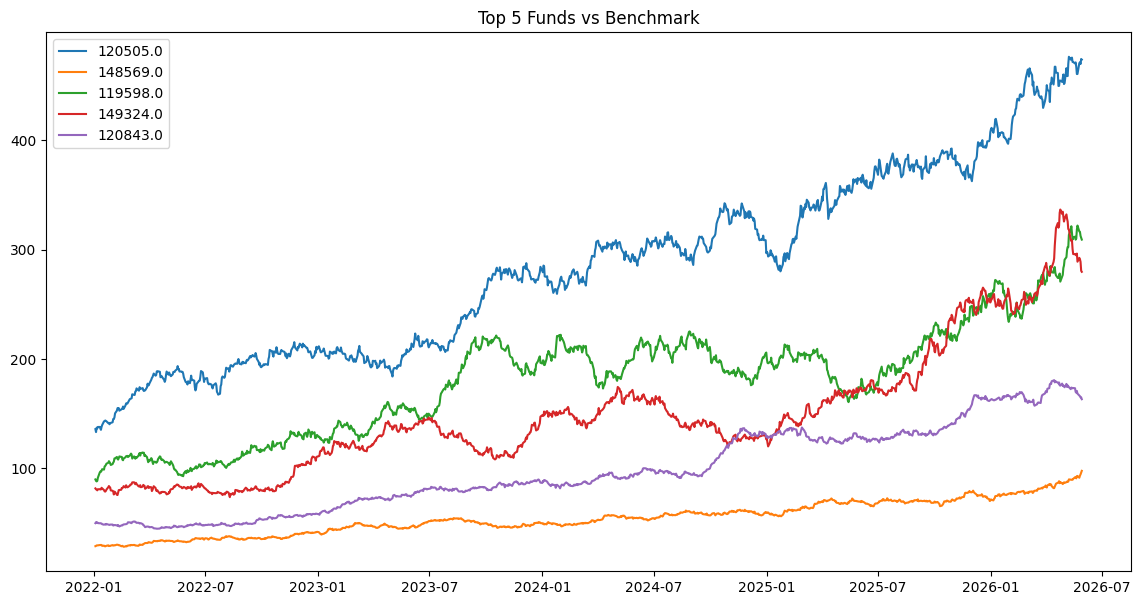

In [36]:
plt.figure(figsize=(14,7))

for fund in top5["amfi_code"]:

    df = nav[
        nav["amfi_code"] == fund
    ]

    plt.plot(
        df["date"],
        df["nav"],
        label=str(fund)
    )

plt.legend()

plt.title(
    "Top 5 Funds vs Benchmark"
)

plt.savefig(
    "../reports/charts/benchmark_comparison.png"
)

plt.show()

In [37]:
alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

print("alpha_beta.csv saved successfully")

alpha_beta.csv saved successfully
